# Market Field reproducibility companion

## TL;DR

This notebook rebuilds and inspects the evidence reported in the ICLR-formatted
working paper. The tests cover causal-prefix invariance, deterministic state
learning, controlled representation behavior, descriptive calibration
diagnostics, and local snapshot cost. They do not test return predictability,
option profitability, or a physical theory of markets.

## Context and methods

The notebook calls the repository's production Market Field functions through
the paper asset script. The default rerun is offline and requires the frozen
cache produced by a prior refresh. Provider retrieval, canonical row hashes,
sample dates, and adjustment mode are recorded in validation_summary.json.

The daily study covers SPY, QQQ, IWM, TLT, GLD, USO, VNQ, and BTC-USD from
2018-01-01 through the paper as-of date 2026-07-21. Chronological
fit/calibration/evaluation segmentation is performed by production code.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

PAPER_ROOT = Path.cwd().resolve()
assert (PAPER_ROOT / "scripts" / "generate_assets.py").exists(), (
    "Run this notebook with docs/papers/market-field as the working directory."
)
print("Paper package:", PAPER_ROOT.name)
print("Python:", sys.version.split()[0])

Paper package: market-field
Python: 3.13.14


## Data and artifact rebuild

In [2]:
completed = subprocess.run(
    [sys.executable, str(PAPER_ROOT / "scripts" / "generate_assets.py"), "--offline"],
    cwd=PAPER_ROOT,
    check=True,
    capture_output=True,
    text=True,
)
print(completed.stdout)

{
  "status": "ok",
  "paper_as_of": "2026-07-21",
  "assets": 8,
  "derived_rows": 7270,
  "prefix_comparisons": 6688,
  "figures": [
    "calibration_rates.pdf",
    "spy_field_phase.pdf",
    "synthetic_diagnostics.pdf",
    "system_overview.pdf"
  ],
  "tables": [
    "asset_summary.tex",
    "validation_summary.tex"
  ]
}



In [3]:
summary = json.loads(
    (PAPER_ROOT / "results" / "validation_summary.json").read_text(encoding="utf-8")
)
assets = pd.read_csv(PAPER_ROOT / "results" / "asset_summary.csv")
manifest = pd.DataFrame(summary["market_data"])
manifest[
    ["symbol", "rows", "first_observation", "last_observation",
     "adjustment", "canonical_ohlcv_sha256"]
]

,symbol,rows,first_observation,last_observation,adjustment,canonical_ohlcv_sha256
0,SPY,2148,2018-01-02T05:00:00+00:00,2026-07-21T04:00:00+00:00,Yahoo auto_adjust=True,ea77800c08663cb150f1b04125d897e62061d5d0a5e6e6...
1,QQQ,2148,2018-01-02T05:00:00+00:00,2026-07-21T04:00:00+00:00,Yahoo auto_adjust=True,00ce949bf1318fadab102ae859cb9ac5f73454ad78f8fb...
2,IWM,2148,2018-01-02T05:00:00+00:00,2026-07-21T04:00:00+00:00,Yahoo auto_adjust=True,60edd0ee5b7d9d9dad098d831128638252f0bdda2665c9...
3,TLT,2148,2018-01-02T05:00:00+00:00,2026-07-21T04:00:00+00:00,Yahoo auto_adjust=True,0089ee8a52a195ee1ca36467d31ab495df16ea608b450e...
4,GLD,2148,2018-01-02T05:00:00+00:00,2026-07-21T04:00:00+00:00,Yahoo auto_adjust=True,f004bce65315d319e6724423f4da6356f6dbc8e462fcea...
5,USO,2148,2018-01-02T05:00:00+00:00,2026-07-21T04:00:00+00:00,Yahoo auto_adjust=True,de1a67bbfedec724465db2c5f927e9342001843a698a07...
6,VNQ,2148,2018-01-02T05:00:00+00:00,2026-07-21T04:00:00+00:00,Yahoo auto_adjust=True,519c362eb2510bfd30134a1282e2a1af20bf18a22d688b...
7,BTC-USD,3124,2018-01-01T00:00:00+00:00,2026-07-21T00:00:00+00:00,Yahoo auto_adjust=True,07faa51bb53f39f7e8c78064fc0d9ea2200cb869553577...


## Results

The following assertions are executable claim guards. They intentionally stop
short of any predictive or economic-performance assertion.

In [4]:
validation = summary["validation"]
synthetic = summary["synthetic"]
benchmark = summary["option_snapshot_benchmark"]

assert validation["prefix_invariance"]["nonzero_differences"] == 0
assert validation["prefix_invariance"]["serialized_value_comparisons"] == 6688
assert validation["determinism"]["exact_lexicon_matches"] == 8
assert synthetic["horizon_delay_spearman_rho"] == 1.0
assert benchmark["rank_influence"] == 0.0
assert benchmark["automated_execution_enabled"] is False

pd.DataFrame(
    [
        {
            "diagnostic": "Prefix invariance",
            "result": (
                f'{validation["prefix_invariance"]["serialized_value_comparisons"]:,} '
                "comparisons; zero mismatches"
            ),
        },
        {
            "diagnostic": "Dictionary determinism",
            "result": (
                f'{validation["determinism"]["exact_lexicon_matches"]}/'
                f'{validation["determinism"]["symbols"]} exact reruns'
            ),
        },
        {
            "diagnostic": "Synthetic horizon delay",
            "result": f'Spearman rho = {synthetic["horizon_delay_spearman_rho"]:.3f}',
        },
        {
            "diagnostic": "Supported distance tails",
            "result": (
                f'{100 * validation["distance_tail"]["pooled_outside_range_rate"]:.2f}% '
                "outside descriptive range"
            ),
        },
        {
            "diagnostic": "Compact snapshot",
            "result": (
                f'{benchmark["median_ms"]:.1f} ms median; '
                f'{benchmark["median_payload_bytes"]:,} bytes'
            ),
        },
    ]
)

,diagnostic,result
0,Prefix invariance,"6,688 comparisons; zero mismatches"
1,Dictionary determinism,8/8 exact reruns
2,Synthetic horizon delay,Spearman rho = 1.000
3,Supported distance tails,5.46% outside descriptive range
4,Compact snapshot,"104.2 ms median; 1,592 bytes"


In [5]:
asset_display = assets[
    [
        "symbol", "bars", "forms", "fit_silhouette",
        "tail_supported_bars", "outside_range_rate",
        "transitions_per_100_bars",
    ]
].copy()
asset_display["fit_silhouette"] = asset_display["fit_silhouette"].map("{:.3f}".format)
asset_display["outside_range_rate"] = asset_display["outside_range_rate"].map("{:.2%}".format)
asset_display["transitions_per_100_bars"] = asset_display[
    "transitions_per_100_bars"
].map("{:.2f}".format)
asset_display

,symbol,bars,forms,fit_silhouette,tail_supported_bars,outside_range_rate,transitions_per_100_bars
0,SPY,2148,2,0.320,860,10.58%,2.56
1,QQQ,2148,1,0.000,860,4.42%,0.00
2,IWM,2148,1,0.000,860,6.63%,0.00
3,TLT,2148,1,0.000,860,3.26%,0.00
4,GLD,2148,1,0.000,860,6.63%,0.00
5,USO,2148,3,0.315,827,6.77%,1.98
6,VNQ,2148,1,0.000,860,1.51%,0.00
7,BTC-USD,3124,1,0.000,1250,4.40%,0.00


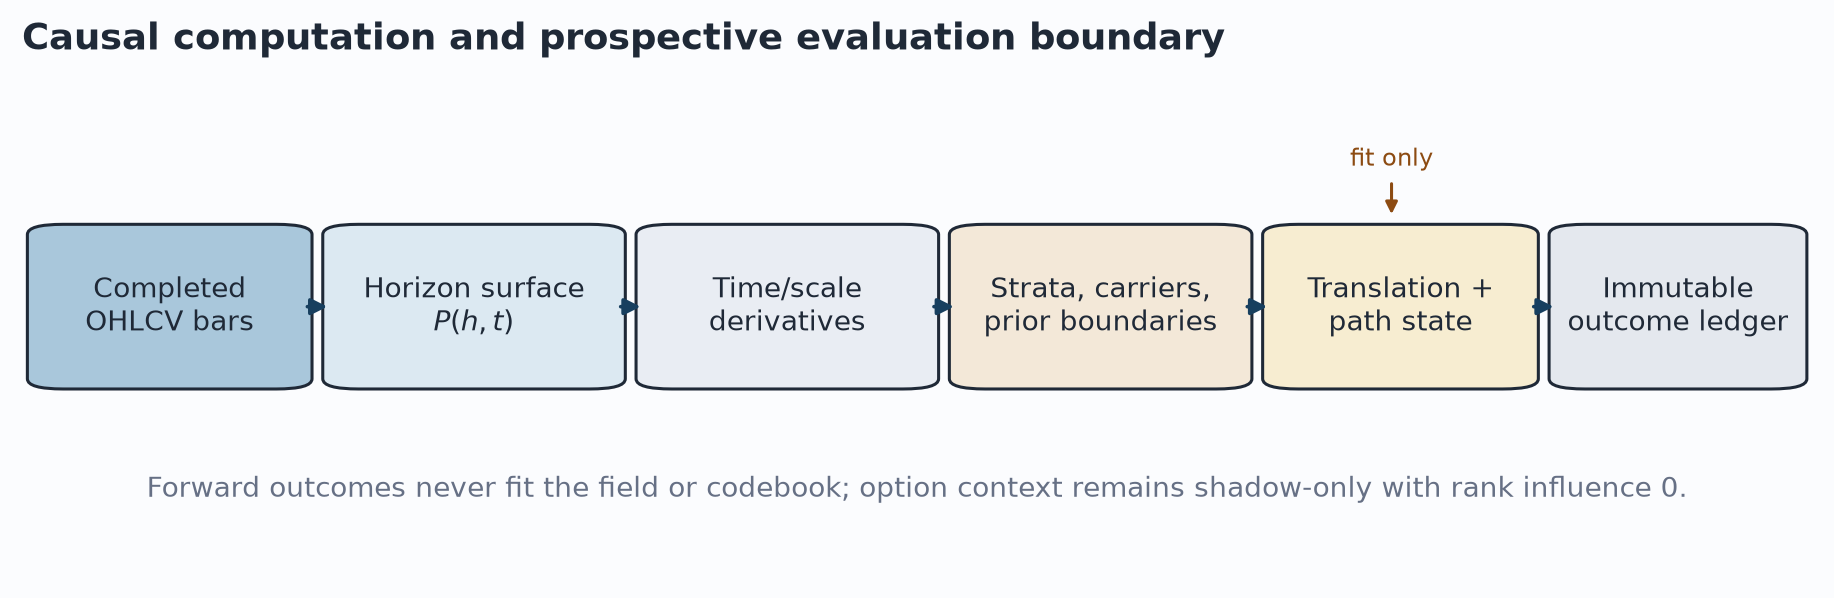

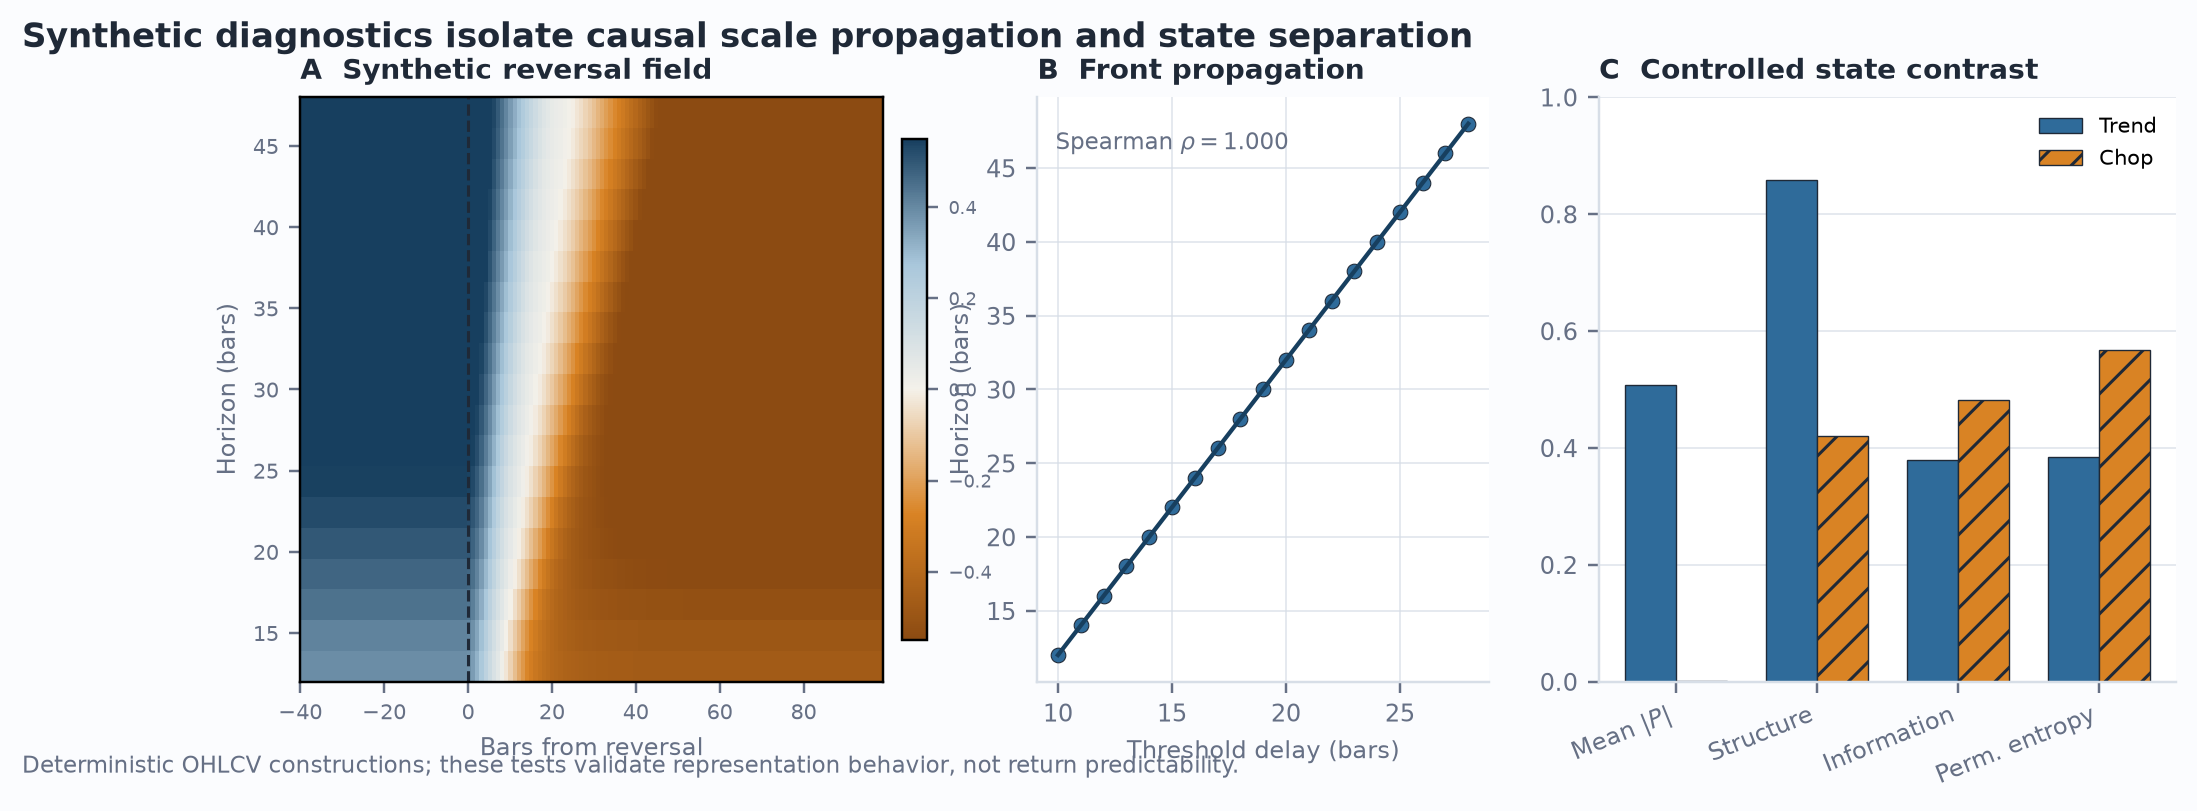

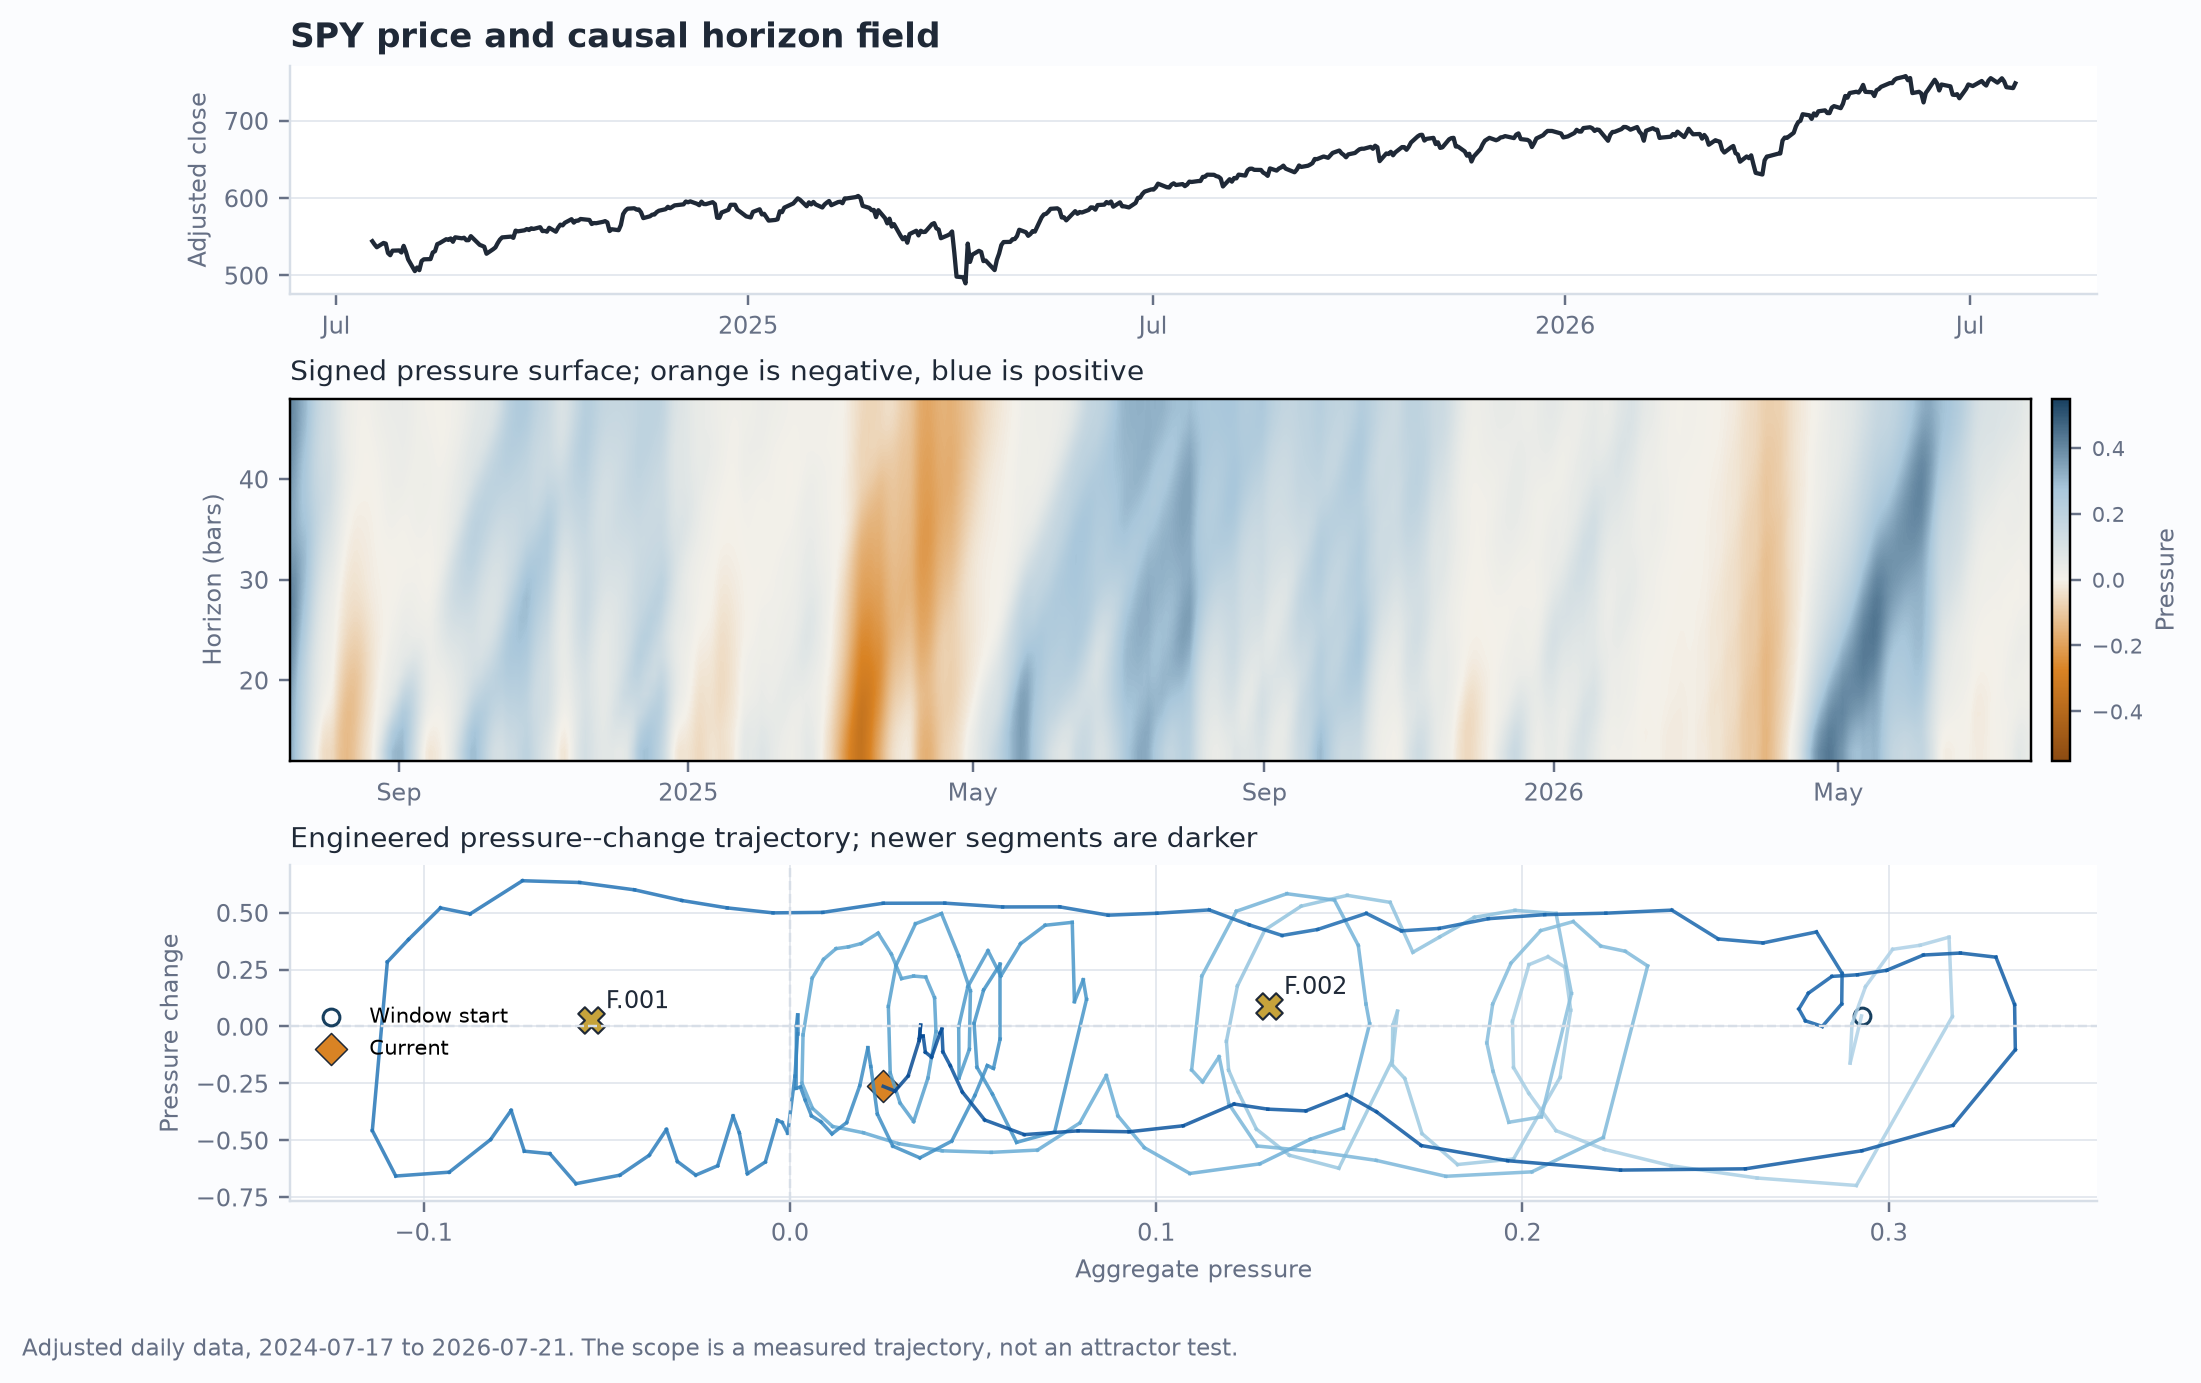

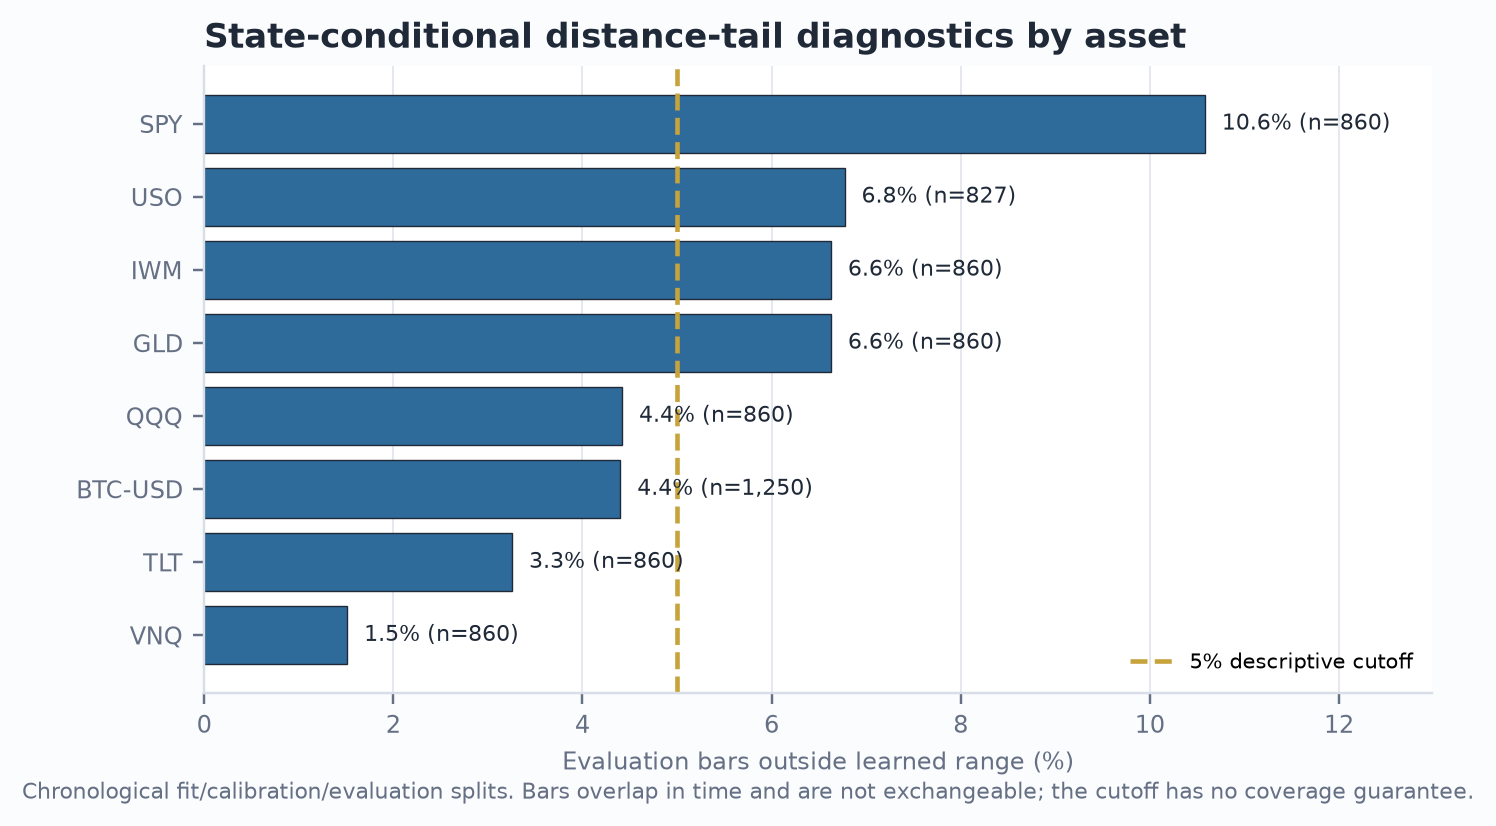

In [6]:
for filename in [
    "system_overview.png",
    "synthetic_diagnostics.png",
    "spy_field_phase.png",
    "calibration_rates.png",
]:
    display(Image(filename=str(PAPER_ROOT / "figures" / filename), width=1050))

## Takeaways

1. Tested serialized channels are prefix-invariant for the selected assets and
   cut points.
2. Fixed inputs produce deterministic request-local dictionaries.
3. Controlled paths generate the intended directional and scale response.
4. Six of eight daily assets fall back to one Form, demonstrating restraint
   and also limiting the current dictionary's descriptive contribution.
5. Distance-tail rates are heterogeneous and must not be read as calibrated
   probabilities.
6. The option snapshot is operationally compact in a local compute-only test,
   while ranking and execution remain disabled.

Future evidence must be rolling-origin, purged, cost-aware, and prospectively
registered before any statement about option outcomes or trading value.